## 0- Objectifs :

Cette partie a pour but de créer notre prédicteur en fonction des données récupérées et stockées dans Cassandra

## 1- Chargement des librairies nécessaires :

In [10]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, DateType,time
from pyspark.sql.functions import month, dayofweek, hour, udf, lit, col
from pyspark.sql.functions import first
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler
import pyspark.sql.functions as F

# Création de la session Spark avec le connecteur Cassandra
spark = SparkSession.builder \
    .appName("Creation_modele_consommation_elec") \
    .config("spark.cassandra.connection.host", "172.17.0.3") \
    .config("spark.cassandra.connection.port", "9042") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

## 2- Récupérations des données et création du dataframe global : 

In [11]:
###On récupère nos données dans Cassandra

In [12]:
mesures_des_stations = spark.read.format("org.apache.spark.sql.cassandra").options(table="mesures_stations", keyspace="consom").load()
consommation = spark.read.format("org.apache.spark.sql.cassandra").options(table="consommation_elec_reelle", keyspace="consom").load()

In [13]:
#On regroupe les variables des stations en colonne 
#On converti les colonnes des mesures en double 
from pyspark.sql.types import DoubleType, IntegerType
import pyspark.sql.functions as F
mesures_des_stations = mesures_des_stations.withColumn("t", F.col("t").cast(DoubleType()))
groupe_colonnes = mesures_des_stations.groupBy('timestamp', "saison","mois","jour","heure")
pivot_mesures_des_stations = groupe_colonnes.pivot('id_station').agg(\
    first("t").alias("t"))

#On doit convertir le timestamp en date_mesure à cause de la jointure : 
pivot_mesures_des_stations= pivot_mesures_des_stations.withColumnRenamed("timestamp", "date_mesure")

#On garde les colonnes en mémoire: 
colonnes_a_garder = pivot_mesures_des_stations.columns
#On ajouter la consommation electrique : 
colonnes_a_garder.append("consommation")
#On supprime le mois 
colonnes_a_garder.remove("mois")
#colonnes_a_garder.remove("jour")
#On joint 
tableau_final = pivot_mesures_des_stations.join(consommation, pivot_mesures_des_stations["date_mesure"] == consommation["timestamp"], "inner")
tableau_final = tableau_final.select([col(c) for c in colonnes_a_garder])

#On renomme date_mesure
tableau_final= tableau_final.withColumnRenamed("date_mesure","timestamp")


## 3- Statistiques complémentaires :

Certaines analyses ont été réalisées sur les données journalières de ces mêmes stations dans le fichier '0- Exploration d'un échantillon de données.ipynb'. Ici, on vérifie les données horaires  avec un tableau de corrélations et des diagrammes de dispersion

### a - Matrice de corrélation et diagrammes de dispersions :

In [14]:
#On créé le tableau des corrélations 
pivot = tableau_final.toPandas()
#Par défaut pearson pour les liens linéaires
correlations = pivot.corr()
correlations.to_csv("Stations/corr.csv",sep=";",header=True)

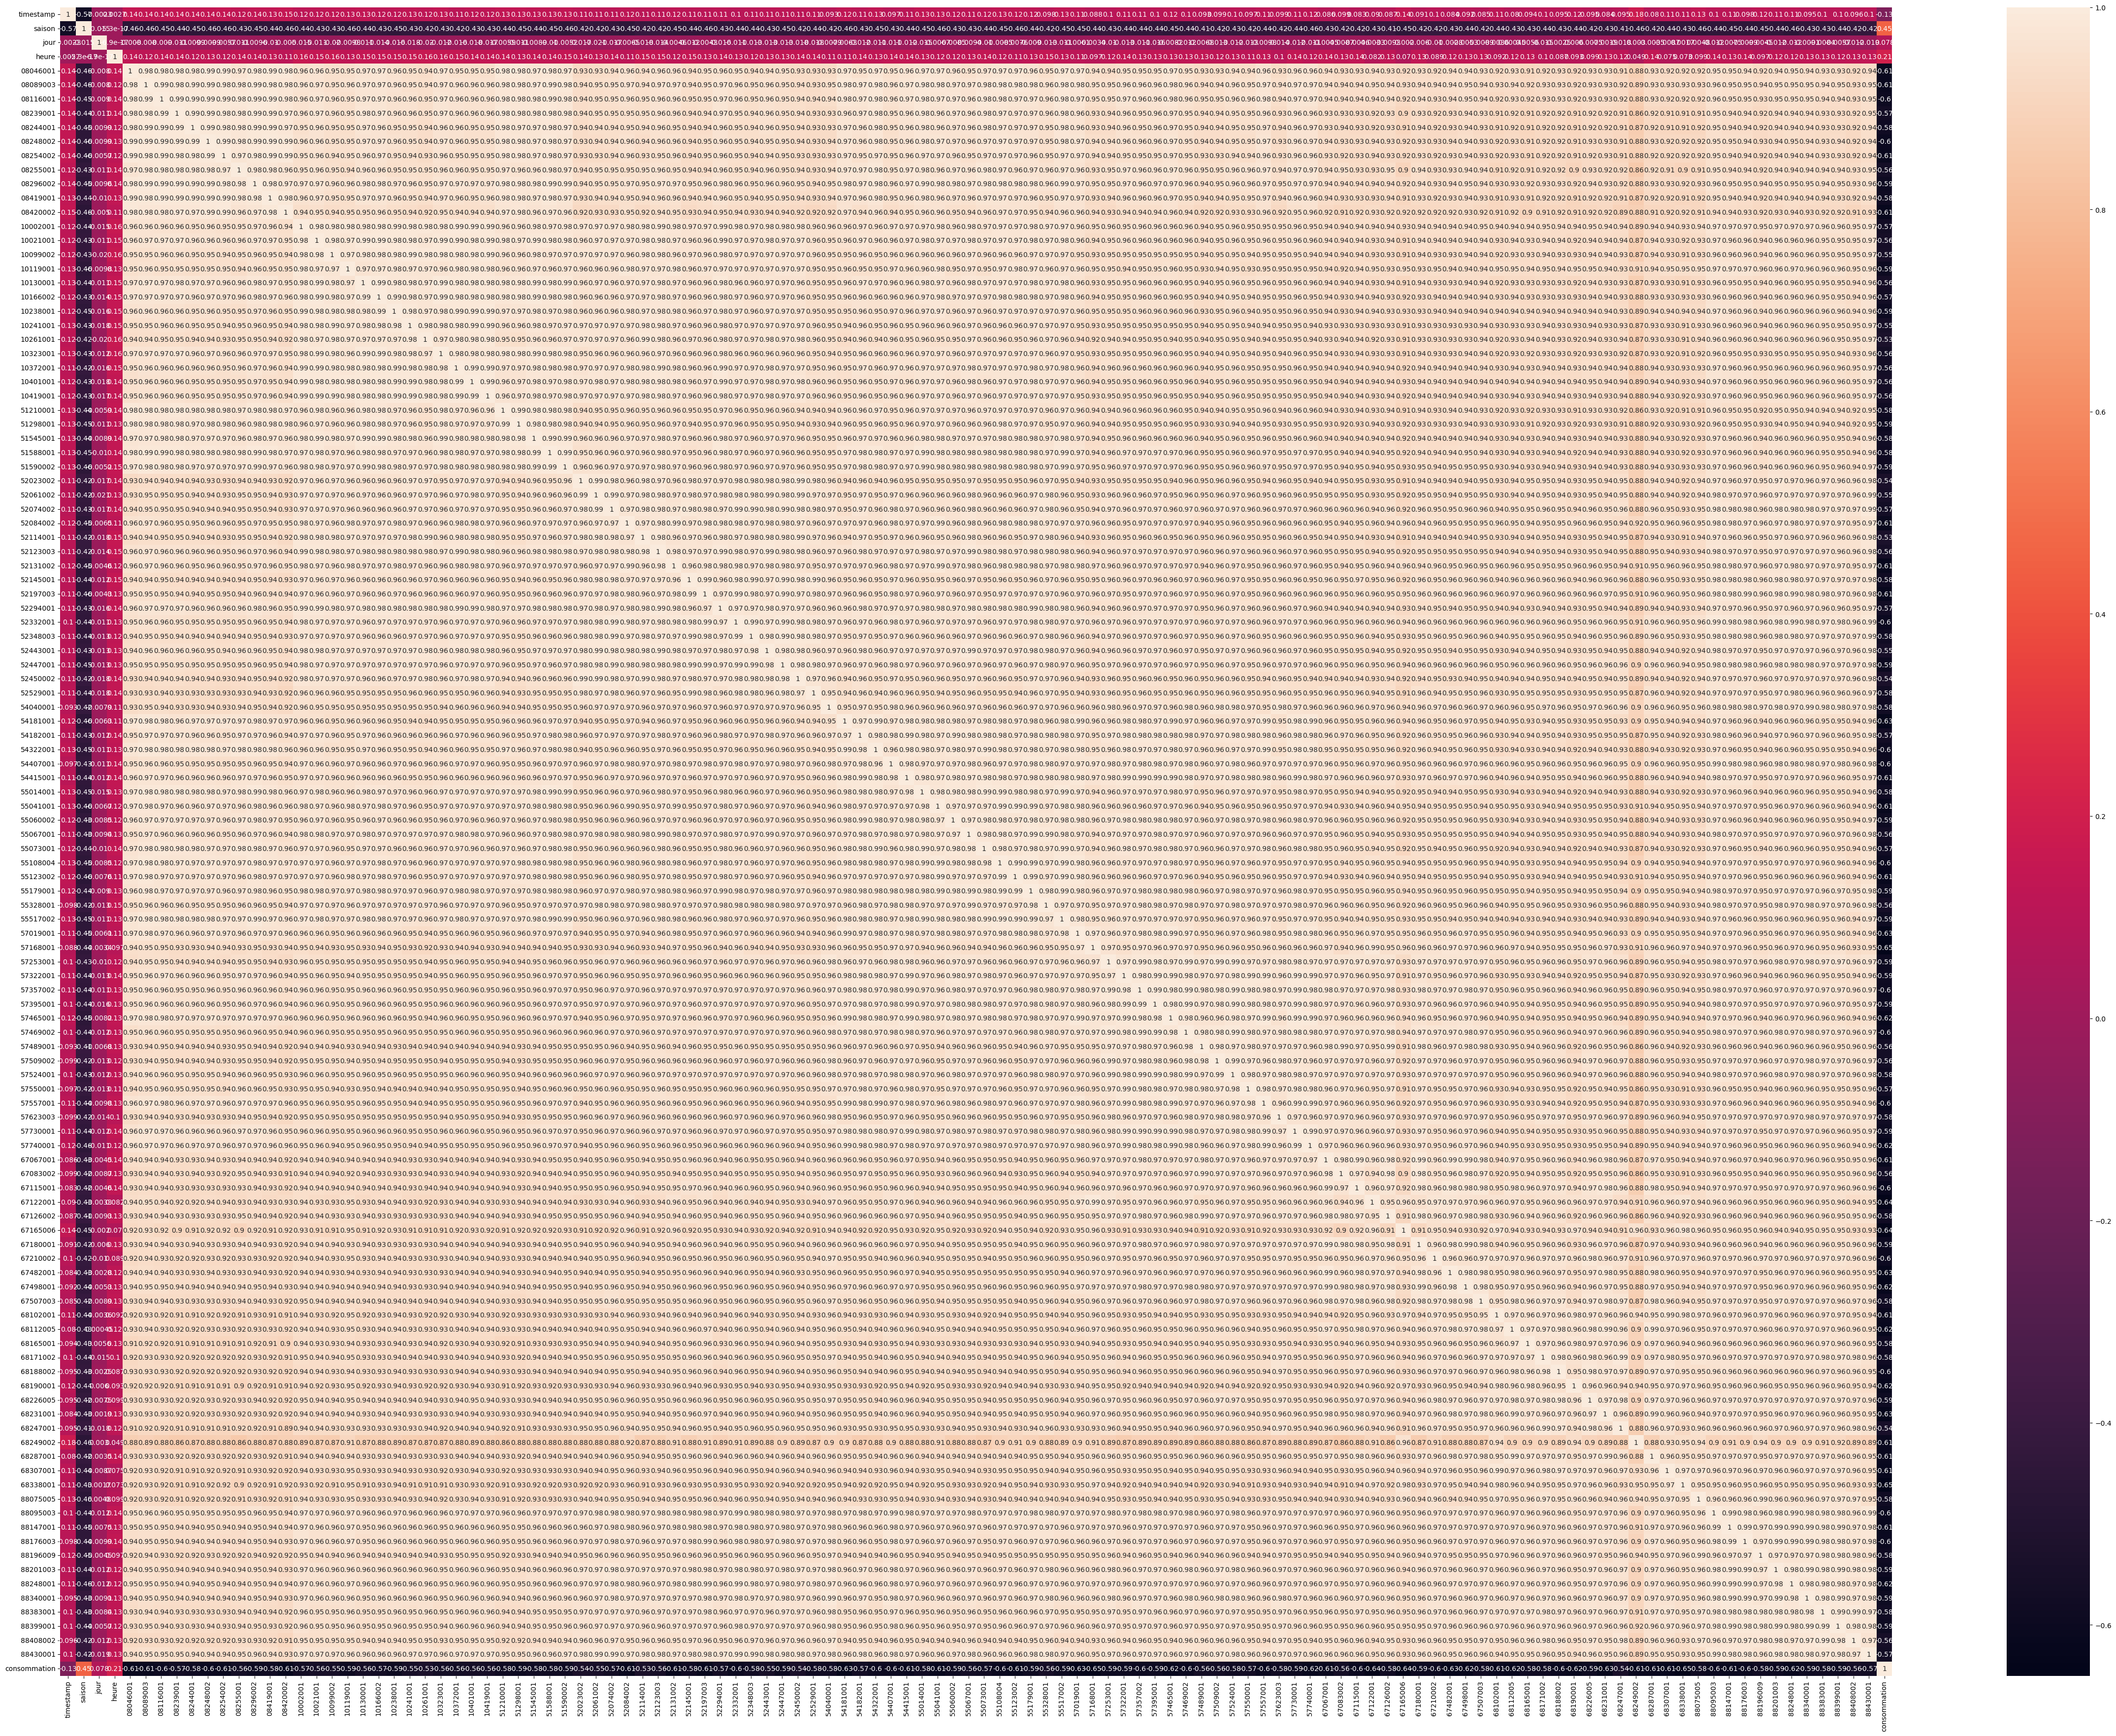

In [74]:
#On sauvegarde la matrice de corrélation : 
import seaborn as sns
import matplotlib.pyplot as plt 
plt.figure(figsize=(60, 44))
sns.heatmap(correlations, annot=True)
plt.savefig("correlation.jpeg")

la corrélation entre la consommation et les températures est toujours négative 

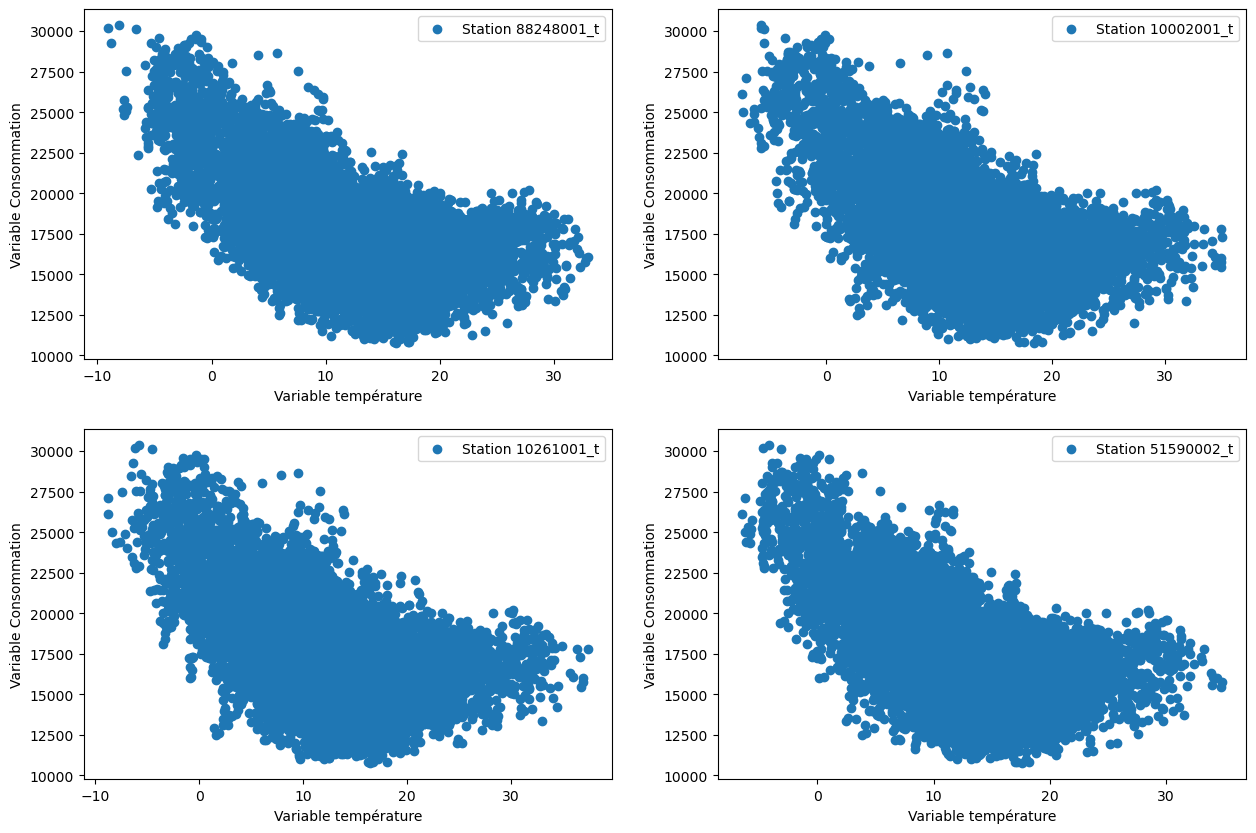

In [15]:
#Afin d'essayer de mieux comprendre les liens entre la température et la consommation, on crée quelques diagrammes de dispersion.
import matplotlib.pyplot as plt 
fix, ax = plt.subplots(2,2,figsize=(15,10))
ax[0,0].scatter(pivot['88248001'], pivot['consommation'],label='Station 88248001_t')
ax[0,0].set_xlabel('Variable température')
ax[0,0].set_ylabel('Variable Consommation')

ax[0,1].scatter(pivot['10002001'], pivot['consommation'],label='Station 10002001_t')
ax[0,1].set_xlabel('Variable température')
ax[0,1].set_ylabel('Variable Consommation')
ax[1,0].scatter(pivot['10261001'], pivot['consommation'],label='Station 10261001_t')
ax[1,0].set_xlabel('Variable température')
ax[1,0].set_ylabel('Variable Consommation')
ax[1,1].scatter(pivot['51590002'], pivot['consommation'],label='Station 51590002_t')
ax[1,1].set_xlabel('Variable température')
ax[1,1].set_ylabel('Variable Consommation')
ax[0,0].legend()
ax[0,1].legend()
ax[1,0].legend()
ax[1,1].legend()
plt.show()

Ci-dessus, on peut observer que la consommation diminue en fonction de l'augmentation de la température, puis à partir d'une certaine valeur positive, elle se remet  à augmenter. Le lien n'est donc pas totalement linéaire.
Une supposition assez plausible  est que la consommation augmente hiver à cause du chauffage, puis à partir d'une certaine valeur positive, elles se remettent à augmenter en cas de chaleur avec les différents appareils de ventilation.

En somme, il sera sans doute nécessaire d'introduire de la non-linéarité dans notre modèle, c'est à dire que la régression linéaire multiple risque de ne pas être assez performante. 

### c - Recherche des vecteurs et des valeurs propres :

In [13]:
#On récupère la liste des colonnes sauf la valeur date et consommation
tableau_final_2= tableau_final.withColumnRenamed('consommation','label')
#tableau_final.columns
listecolonnes= tableau_final_2.columns
listecolonnes.remove('label')
# Il est intéressant de le garder
listecolonnes.remove('timestamp')

On regroupe les colonnes à analyser du DataFrame spamDF dans une nouvelle colonne de type Vector en utilisant le VectorAssembler :

In [14]:
from pyspark.ml.linalg import Vectors
from pyspark.ml.feature import VectorAssembler

# Construction du VectorAssembler
assembleur = VectorAssembler().setInputCols(listecolonnes).setOutputCol("features")
# Construction du Dataframe spamDFA en appliquant le VectorAssembler
mesures = assembleur.transform(tableau_final_2[listecolonnes])

On normalise les variables avant application de l’ACP

In [15]:
from pyspark.ml.feature import StandardScaler

# Construction d'une nouvelle instance d'estimateur StandardScaler
scaler = StandardScaler().setInputCol("features").setOutputCol("scaledFeatures") \
                         .setWithStd(True).setWithMean(True)
# Syntaxe équivalente :
#scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", \
#                         withStd=True, withMean=True)

# Application de la nouvelle instance d'estimateur StandardScaler
scalerModel = scaler.fit(mesures)
scaledMesures = scalerModel.transform(mesures).select("scaledFeatures")

On applique l'ACP afin de déterminer les principales composantes et vecteurs propres : 

In [51]:
from pyspark.ml.feature import PCA
#https://cedric.cnam.fr/vertigo/Cours/RCP216/tpComposantesPrincipalesPy.html#analyse-en-composantes-principales-acp
# Construction et application d'une nouvelle instance d'estimateur PCA
pcaModel = PCA().setInputCol("scaledFeatures").setOutputCol("pcaFeatures") \
                .setK(10).fit(scaledMesures)

# Application du « transformateur » PCAModel résultant de l'estimation
resultat = pcaModel.transform(scaledMesures).select("pcaFeatures")

# Les 5 plus grandes valeurs propres (exprimées en proportion de variance expliquée)
print(pcaModel.explainedVariance)

# Vecteurs propres correspondants
print(pcaModel.pc)

[0.9429736145527838,0.011077562050041012,0.009073547214740468,0.006932085966591512,0.005925233517752071,0.004688359510829708,0.002200795036791967,0.0018020402108476256,0.0013835372275377087,0.000987130812145709]
DenseMatrix([[-0.04327468, -0.01434337, -0.40886881, ...,  0.00084675,
              -0.08291134,  0.02411546],
             [ 0.01253926,  0.36485506, -0.77048651, ...,  0.05478488,
               0.00671245, -0.00165867],
             [ 0.09330269,  0.12421763,  0.08137687, ...,  0.00730292,
              -0.1243087 , -0.04270632],
             ...,
             [ 0.09437661, -0.08771507, -0.02984669, ...,  0.07154857,
              -0.02715623, -0.15919963],
             [ 0.09343852, -0.1013517 , -0.07101299, ...,  0.22425593,
              -0.07627011, -0.05711663],
             [ 0.09466156, -0.01853219, -0.04166656, ..., -0.03134551,
              -0.11141881, -0.05026113]])


In [12]:
print(pcaModel.explainedVariance)

[0.9269787818825441,0.01288491695331413,0.010742036107166763,0.008569510023520103,0.00824618736044476]


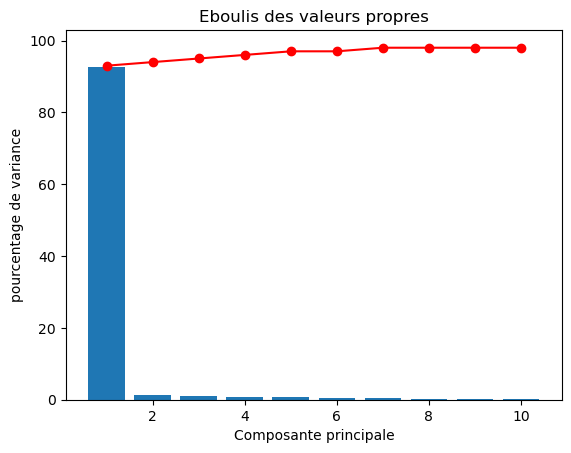

In [15]:
variance = (pcaModel.explainedVariance*100).round(2)
variance_cumulee = variance.cumsum().round()
plt.bar(list(range(1, 10+1)), variance)
plt.plot(list(range(1, 10+1)), variance_cumulee,c="red",marker='o')
plt.xlabel("Composante principale")
plt.ylabel("pourcentage de variance")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

La variance cumulée est d'environ 90% sur les deux premières composante.

## 4- Création du modèle prédictif :

### a- Import des bibliothèques :

In [16]:
from pyspark.ml.feature import StandardScaler, PCA
from pyspark.ml.tuning import CrossValidator, CrossValidatorModel, ParamGridBuilder
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import LinearRegression
from pyspark.ml import Pipeline, PipelineModel

In [17]:
#tableau_final.columns
tableau_final_2= tableau_final.withColumnRenamed('consommation','label')
listecolonnes= tableau_final_2.columns
listecolonnes.remove('label')
listecolonnes.remove('timestamp')

### b- Découpage des données pour l'entrainement et création des pipelines :

In [18]:
 #1- Vecteur assembleur : 
assembleur = VectorAssembler().setInputCols(listecolonnes).setOutputCol("features")
# Construction du Dataframe mesures en appliquant le VectorAssembler
mesures = assembleur.transform(tableau_final_2).select('timestamp','features', 'label').cache()
# Partitionnement des données en un jeu apprentissage (80%) et un jeu de test (20%)
partitions = mesures.randomSplit([0.8, 0.2], seed=10)
apprentissage = partitions[0]  # conservé en mémoire
test = partitions[1]

### c- Pipeline 1 avec la régression logistique :

In [19]:
# Définition du scaler pour centrer et réduire les variables initiales
scaler = StandardScaler().setInputCol("features") \
                         .setOutputCol("scaledFeatures") \
                         .setWithStd(True) \
                         .setWithMean(True)
# Construction et application d'une nouvelle instance d'estimateur PCA
pca = PCA().setInputCol("scaledFeatures").setOutputCol("pcaFeatures")
# Définition de la régression linéaire
lr = LinearRegression().setMaxIter(value=200).setFeaturesCol("pcaFeatures").setLabelCol("label")#(maxIter=, regParam=0.3, elasticNetParam=0.8)
# Définition du pipeline (réduit ici au SVM linéaire)
pipelineA = Pipeline().setStages([scaler, pca, lr])

In [20]:
evaluator = RegressionEvaluator(metricName="rmse")

paramGridA = ParamGridBuilder() \
                     .addGrid(pca.k, [2,5,10]) \
                     .addGrid(lr.regParam,[0.3,0.6,0.9,1])\
                     .addGrid(lr.elasticNetParam,[0.6,0.8,1])\
                     .build()

cvA = CrossValidator().setEstimator(pipelineA) \
                      .setEstimatorParamMaps(paramGridA) \
                      .setNumFolds(5) \
                      .setEvaluator(RegressionEvaluator(metricName="rmse"))

In [9]:
lrmodelA = cvA.fit(apprentissage)
lrmodelA.avgMetrics

[2650.7926238225464,
 2650.7928053979717,
 2650.7929881950513,
 2650.7932216933123,
 2650.793598224303,
 2650.7939796438063,
 2650.7938580079476,
 2650.7944428772817,
 2650.795038750028,
 2650.7940786544814,
 2650.7947359443347,
 2650.795406820401,
 2387.967856944305,
 2387.9679193408188,
 2387.9679860178876,
 2387.968009510138,
 2387.9681765943474,
 2387.9683608067776,
 2387.9682563757356,
 2387.9685704443064,
 2387.9689230648714,
 2387.968359616279,
 2387.968732079844,
 2387.969152144013,
 2110.09067204648,
 2110.091132555721,
 2110.0916042996555,
 2110.0920756028413,
 2110.0930990310544,
 2110.0941674124474,
 2110.093677510419,
 2110.0953662771008,
 2110.097156220806,
 2110.09425555026,
 2110.0961888579945,
 2110.0982470889453]

In [43]:
# Calcul des résultats de test
resultatsA = lrmodelA.transform(test)

# Évalution des métriques de test
lrmodelA.getEvaluator().evaluate(resultatsA)

2206.216019825905

In [52]:
resultatRL = resultatsA.toPandas()
#resultat.to_csv("Stations/sauvegardetest.csv",sep=";")

### d- Pipeline 2 avec ramdom forest (avec plusieurs configurations) :

In [21]:
from pyspark.ml.regression import RandomForestRegressor

rf = RandomForestRegressor().setFeaturesCol("pcaFeatures").setLabelCol("label")

#### Premiere configuration 

In [22]:
paramGridR = ParamGridBuilder() \
                     .addGrid(pca.k, [2,3,5]) \
                     .addGrid(rf.numTrees,[100,120])\
                     .addGrid(rf.maxDepth,[10])\
                     .build()

pipelineR = Pipeline().setStages([scaler, pca, rf])

cvR = CrossValidator().setEstimator(pipelineR) \
                      .setEstimatorParamMaps(paramGridR) \
                      .setNumFolds(5) \
                      .setEvaluator(RegressionEvaluator(metricName="rmse"))

#### Deuxième configuration 

In [21]:
paramGridR = ParamGridBuilder() \
                     .addGrid(pca.k, [30]) \
                     .addGrid(rf.numTrees,[120])\
                     .addGrid(rf.maxDepth,[10])\
                     .build()

pipelineR = Pipeline().setStages([scaler, pca, rf])

cvR = CrossValidator().setEstimator(pipelineR) \
                      .setEstimatorParamMaps(paramGridR) \
                      .setNumFolds(5) \
                      .setEvaluator(RegressionEvaluator(metricName="rmse"))


#### Troisième configuration (la plus performante)

In [23]:
paramGridR = ParamGridBuilder() \
                     .addGrid(pca.k, [5]) \
                     .addGrid(rf.numTrees,[120])\
                     .addGrid(rf.maxDepth,[12])\
                     .build()

pipelineR = Pipeline().setStages([scaler, pca, rf])

cvR = CrossValidator().setEstimator(pipelineR) \
                      .setEstimatorParamMaps(paramGridR) \
                      .setNumFolds(5) \
                      .setEvaluator(RegressionEvaluator(metricName="rmse"))

In [24]:
rfmodelA = cvR.fit(apprentissage)
rfmodelA.avgMetrics

[1320.6105889500118]

In [26]:
# Calcul des résultats de test
resultatsR = rfmodelA.transform(test)

# Évalution des métriques de test
rfmodelA.getEvaluator().evaluate(resultatsR)

1334.8471450330524

In [ ]:
#Sauvegarde du meilleure modèle: 

In [17]:
best_model = rfmodelA.bestModel

best_model.write().save("Predicteurs/ModelFinal2025")
#best_model.write().overwrite().save("Predicteurs/RFModelGE09022025Test3")

### e- Calcul de MAPE et affichage des données de test :

Le code ci-dessous va :
- calculer le Mean Absolute Percentage Error, alias MAPE à partir des prédictions réalisées sur le jeu de test (cette mesure ne semble pas disponible dans Spark)
- Afficher ensuite les résultats dans un graph :
https://en.wikipedia.org/wiki/Mean_absolute_percentage_error

In [27]:
#On converti notre dataframe de test dans Pandas pour faire le calcul
resultat = resultatsR.toPandas()

In [28]:
#On calcul les écarts entre la valeur réelle et la valeur prédite 
resultat['ecartM'] = abs((resultat['label']- resultat['prediction'])/resultat['label'])
MAPE= 100*(resultat['ecartM'].mean())
print("Mean Absolute Percentage Error :"+str(round(MAPE,2))+"%")

Mean Absolute Percentage Error :5.75%


In [30]:
dfpandas = resultat

### f- Affichage du graph entre les prédictions réalisées et les valeurs réelles du jeu de test :

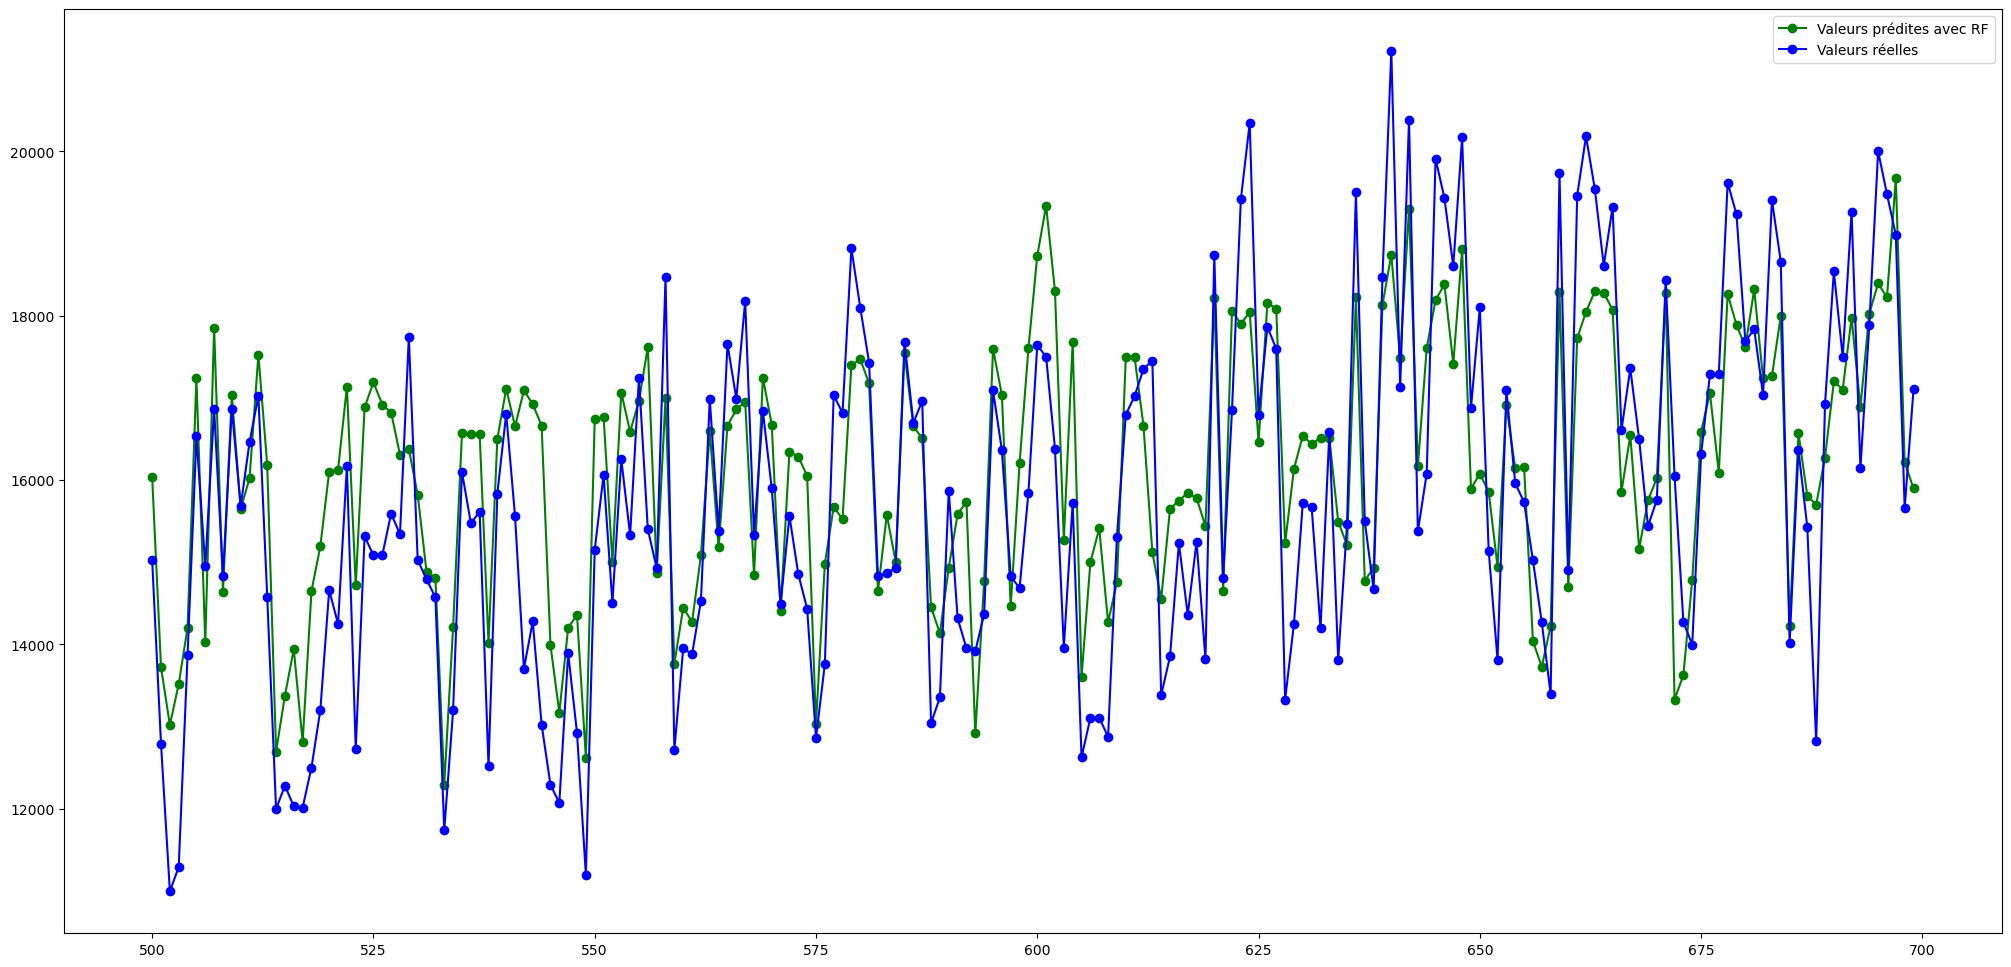

In [31]:
#On compare la prédiction réalisée à la consommation réelle en affichant directement les résultats : 
import matplotlib.pyplot as plt
plt.figure(figsize=(25,12))
# Tracer les valeurs réelles
#y_test_2 = y_test.reset_index(drop=True)
#plt.plot(y_predict_ridge, label="Valeurs prédites ridge", color='red', marker='o')
plt.plot(dfpandas['prediction'].iloc[500:700], label="Valeurs prédites avec RF", color='green', marker='o')
plt.plot(dfpandas['label'].iloc[500:700], label="Valeurs réelles", color='blue', marker='o')
plt.legend()

Sur le graph ci-dessus, nous pouvons voir que même s’il existe un léger écart entre la consommation réelle et la consommation prédite, le modèle semble très souvent suivre les variations de la consommation réelle.
Il existe toutefois des variations que le modèle ne prend pas encore en compt et que nous allons regarder.


In [96]:
spark.stop()